# Lab 6.2: Gradient Descent for Linear Regression

**Student Name:** Malik Awais Bashir
**Registration Number:** 22JZELE0474  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Goal of this lab
* Create sample data representing a linear relationship between variables.
* Scale both input and output data before implementing gradient descent.
* Adjust model coefficients iteratively using gradient descent optimization.
* Learn the process of transforming normalized model parameters back to their original physical units.


## Section 1: Data Generation and Normalization
This section creates the synthetic dataset and normalizes the values so gradient descent can run more smoothly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ── 1. Data Generation ───────────────────────────────────────────────────────
np.random.seed(42)                        # reproducible results
R_true = 1000                             # Ω

I_flat = np.linspace(0, 0.01, 50)        # 0 to 10 mA in Amperes
V_clean = R_true * I_flat                 # 0 to 10 V
noise   = np.random.normal(0, 0.05, size=I_flat.shape)  # noise std 0.05 V (was 0.2!)
V_noisy = V_clean + noise

In [2]:
# ── 3. Normalize for Gradient Descent ────────────────────────────────────────
I_mean, I_std = I_flat.mean(), I_flat.std()
V_mean, V_std = V_noisy.mean(), V_noisy.std()

I_norm = (I_flat - I_mean) / I_std
V_norm = (V_noisy - V_mean) / V_std

## Section 2: Gradient Descent Training
The following cells apply gradient descent to learn the slope and intercept by minimizing prediction error.


Converged at epoch 136

GD slope     : 997.10 Ω  (expected 1000)
GD intercept : 0.0034 V  (expected ~0)


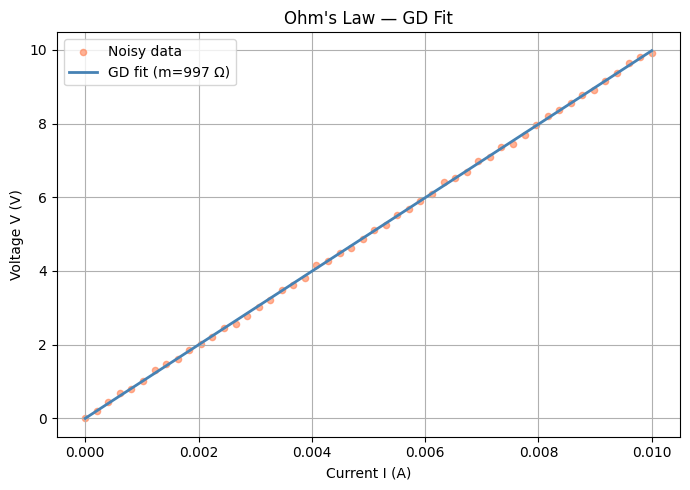

In [3]:
# ── 4. Gradient Descent ───────────────────────────────────────────────────────
alpha = 0.05
m, b  = 1.0, 100.0
loss_history = []

for epoch in range(500):
    V_pred = m * I_norm + b
    error  = V_pred - V_norm

    loss = (error ** 2).mean()
    loss_history.append(float(loss))

    dm = 2 * (I_norm * error).mean()
    db = 2 * error.mean()

    m -= alpha * dm
    b -= alpha * db

    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < 1e-9:
        print(f"Converged at epoch {epoch}")
        break

# ── 5. Rescale back to physical units ────────────────────────────────────────
m_phys = m * (V_std / I_std)
b_phys = b * V_std + V_mean - m_phys * I_mean

print(f"\nGD slope     : {m_phys:.2f} Ω  (expected 1000)")
print(f"GD intercept : {b_phys:.4f} V  (expected ~0)")

# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(I_flat, V_noisy, s=20, alpha=0.6, color="coral", label="Noisy data")
ax.plot(I_flat, m_phys * I_flat + b_phys,
        color="steelblue", linewidth=2, label=f"GD fit (m={m_phys:.0f} Ω)")
ax.set_xlabel("Current I (A)")
ax.set_ylabel("Voltage V (V)")
ax.set_title("Ohm's Law — GD Fit")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Section 3: Mathematical Explanation and Physical Rescaling
This section explains the equations used in gradient descent and converts the normalized model back to real physical units.


## Conclusion
* In this lab, gradient descent was implemented to estimate the parameters of a linear regression model.
* The optimization process was carried out iteratively to minimize prediction error.
* Data normalization was applied to improve the efficiency and stability of model training.
* The learned parameters were transformed back to their original scale for practical interpretation.
* This approach helped relate the mathematical optimization process to real-world engineering applications.



